In [1]:
import sys

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import csv
from datasets import load_from_disk
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from datasets import Dataset, features

from llm_mri import ActivationAreas, Evaluation
from llm_mri.dimensionality_reduction import PCA, UMAP, SVD

from sklearn.datasets import fetch_20newsgroups

import sys
sys.path.insert(0, '../../') 

from utils.nodes1 import get_node_metric_function

from utils.data import csv_to_huggingface_dataset
import random
from fractions import Fraction

/usr/local/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Constants
STRUCTURED_DATASET_PATH = "./data/hf_structured_dataset"
GRAPH_PATH = "./data/interim/graphs"
PROCESSED_DATASET_PATH = "./data/processed/"

# Model
model_ckpt = "bert-base-uncased"

# Get metrics by layer

In [8]:
dataset = load_from_disk(STRUCTURED_DATASET_PATH)
class_names = dataset.features["label"].names


def convert_node_metrics_to_dataframe(metrics_dict):
    """
    Converte dicionários de métricas por nó para um DataFrame.
    
    Args:
        metrics_dict: dicionário {metric_name: {node: value}}
    
    Returns:
        DataFrame com colunas: node, layer, x, y, e uma coluna para cada métrica
    """
    if not metrics_dict:
        return pd.DataFrame()
    
    # Pega o primeiro dicionário de métrica para obter os nós
    first_metric = next(iter(metrics_dict.values()))
    nodes = list(first_metric.keys())
    
    # Extrai layer, x, y de cada nó
    data = []
    for node in nodes:
        row = {"node": node}
        row["layer"] = int(node.split("_")[0])
        row["x"] = int(node.split("_")[1])
        row["y"] = int(node.split("_")[2])
        
        # Adiciona cada métrica
        for metric_name, metric_values in metrics_dict.items():
            row[metric_name] = metric_values.get(node, None)
        
        data.append(row)
    
    return pd.DataFrame(data)


# Calcular as métricas locais para cada grafo filtrado e salvar em CSV
print("=" * 60)
print("CALCULANDO MÉTRICAS LOCAIS POR NÓ")
print("=" * 60)




for label in [*class_names,  "total"]:
    print(f"\nProcessando: {label}")
    
    # Carregar grafo
    graph_path = f"{GRAPH_PATH}/g_{label}.gexf"
    try:
        current_graph = nx.read_gexf(graph_path)
    except FileNotFoundError:
        print(f"  ⚠ Grafo não encontrado: {graph_path}")
        continue
    
    if len(current_graph) == 0:
        print(f"  ⚠ Grafo vazio para {label}")
        continue
    
    # Calcular todas as métricas locais
    metrics_per_node = {}
    for metric_name, metric_func in get_node_metric_function().items():
        try:
            metrics_per_node[metric_name] = metric_func(current_graph)
            print(f"  ✓ {metric_name}")
        except Exception as e:
            print(f"  ✗ Erro em {metric_name}: {str(e)}")
    
    # Converter para DataFrame
    df_metrics = convert_node_metrics_to_dataframe(metrics_per_node)
    
    # Salvar
    output_file = f'{PROCESSED_DATASET_PATH}/metrics_per_node_{label}.csv'
    df_metrics.to_csv(output_file, index=False)
    print(f"  ✓ Salvo em: {output_file}")
    print(f"    - {len(df_metrics)} nós com {len(df_metrics.columns)} colunas")
    
print("\n" + "=" * 60)
print("CONCLUÍDO")
print("=" * 60)

CALCULANDO MÉTRICAS LOCAIS POR NÓ

Processando: LONG_EQUATION_INVALID
  ✓ degree
  ✓ node_betweenness
  ✓ node_strength
  ✓ average_neighbor_degree
  ✗ Erro em eigenvector_centrality: (PowerIterationFailedConvergence(...), 'power iteration failed to converge within 100 iterations')
  ✗ Erro em eccentricity: not implemented for directed type
  ✓ kcore
  ✓ Salvo em: ./data/processed//metrics_per_node_LONG_EQUATION_INVALID.csv
    - 222 nós com 9 colunas

Processando: LONG_EQUATION_VALID
  ✓ degree
  ✓ node_betweenness
  ✓ node_strength
  ✓ average_neighbor_degree
  ✗ Erro em eigenvector_centrality: (PowerIterationFailedConvergence(...), 'power iteration failed to converge within 100 iterations')
  ✗ Erro em eccentricity: not implemented for directed type
  ✓ kcore
  ✓ Salvo em: ./data/processed//metrics_per_node_LONG_EQUATION_VALID.csv
    - 227 nós com 9 colunas

Processando: SHORT_EQUATION_INVALID
  ✓ degree
  ✓ node_betweenness
  ✓ node_strength
  ✓ average_neighbor_degree
  ✗ Erro em

# Aggregate Data

In [ ]:
# Aggregate all metrics into a single DataFrame for easier analysis

# Dicionário para armazenar dados por métrica
metrics_by_label = {}

for label in class_names:
    file_path = f'{PROCESSED_DATASET_PATH}/metrics_per_node_{label}.csv'
    if os.path.exists(file_path):
        df = pd.read_csv(file_path)
        metrics_by_label[label] = df
    else:
        print(f"⚠ Arquivo não encontrado: {file_path}")


#   ✓ degree
#   ✓ node_betweenness
#   ✓ node_strength
#   ✓ average_neighbor_degree
#   ✗ Erro em eigenvector_centrality: (PowerIterationFailedConvergence(...), 'power iteration failed to converge within 100 iterations')
#   ✗ Erro em eccentricity: not implemented for directed type
#   ✓ kcore
available_metrics = ["degree", "node_betweenness", "node_strength", "average_neighbor_degree", "kcore"]
        
if metrics_by_label:
    sample_df = list(metrics_by_label.values())[0]
    # available_metrics = [col for col in sample_df.columns if col not in ['layer', 'layer_description']]
    
    print(f"✓ Carregados {len(metrics_by_label)} labels com {len(available_metrics)} métricas cada")
    print(f"Métricas disponíveis: {available_metrics}\n")
    
    # Para cada métrica, calcular correlação entre as labels
    for metric_name in available_metrics:
        print(f"\n{'='*60}")
        print(f"Métrica: {metric_name}")
        print(f"{'='*60}")
        
        # ============================================
        # ESTRATÉGIA DE MERGE COMPLEXA
        # Usar 'node' como chave de merge ao invés de índices posicionais
        # ============================================
        
        # Começar com o primeiro label
        df_metric_comparison = None
        
        for label in class_names:
            if label in metrics_by_label:
                df = metrics_by_label[label]
                
                # Selecionar apenas as colunas necessárias: node e a métrica atual
                df_temp = df[['node', metric_name]].copy()
                df_temp.rename(columns={metric_name: label}, inplace=True)
                
                if df_metric_comparison is None:
                    # Primeira iteração: usar como base
                    df_metric_comparison = df_temp
                else:
                    # Fazer merge usando 'node' como chave
                    # inner join para manter apenas regiões comuns a TODAS as labels
                    df_metric_comparison = pd.merge(
                        df_metric_comparison,
                        df_temp,
                        on='node',
                        how='outer' 
                        # how='inner'  # Inner join evita NaNs e problemas de variância
                    )
        if df_metric_comparison is None:
            print(f"  ⚠ Nenhuma métrica encontrada para {metric_name}. Pulando.")
        
        
        # Remover a coluna 'node' se quiser apenas os valores das labels
        if df_metric_comparison is not None:
            # Salvar versão com node (para referência)
            df_metric_comparison.to_csv(
                f'{PROCESSED_DATASET_PATH}/aggregate_nodes_{metric_name}_with_node.csv', 
                index=False
            )
            
            # Salvar versão sem node (apenas as métricas)
            df_metric_comparison_no_node = df_metric_comparison.drop('node', axis=1)
            df_metric_comparison_no_node.to_csv(
                f'{PROCESSED_DATASET_PATH}/aggregate_nodes_{metric_name}.csv', 
                index=False
            )
            
            print(f"✓ Merge realizado com sucesso!")
            print(f"  - Regiões (nodes) totais: {len(df_metric_comparison)}")
            print(f"  - Labels processadas: {len(df_metric_comparison.columns) - 1}")
            print(f"  - Valores faltantes (NaN): {df_metric_comparison_no_node.isna().sum().sum()}")
            
            # Mostrar exemplo de merge (primeiras 3 linhas)
            print(f"\n  Exemplo de merge (primeiras 3 linhas):")
            print(df_metric_comparison.head(3).to_string())


✓ Carregados 30 labels com 5 métricas cada
Métricas disponíveis: ['degree', 'node_betweenness', 'node_strength', 'average_neighbor_degree', 'kcore']


Métrica: degree
✓ Merge realizado com sucesso!
  - Regiões (nodes) totais: 1085
  - Labels processadas: 30
  - Valores faltantes (NaN): 19420

  Exemplo de merge (primeiras 3 linhas):
    node  LONG_EQUATION_INVALID  LONG_EQUATION_VALID  SHORT_EQUATION_INVALID  SHORT_EQUATION_VALID  academic_paper  alt.atheism  comp.graphics  comp.os.ms-windows.misc  comp.sys.ibm.pc.hardware  comp.sys.mac.hardware  comp.windows.x  math_formula_retrieval  medical_text  misc.forsale  poem  rec.autos  rec.motorcycles  rec.sport.baseball  rec.sport.hockey  recipe.directions  recipe.ingredients  sci.crypt  sci.electronics  sci.med  sci.space  soc.religion.christian  talk.politics.guns  talk.politics.mideast  talk.politics.misc  talk.religion.misc
0  0_0_6                    2.0                  NaN                     NaN                   NaN             1.0

# Correlation

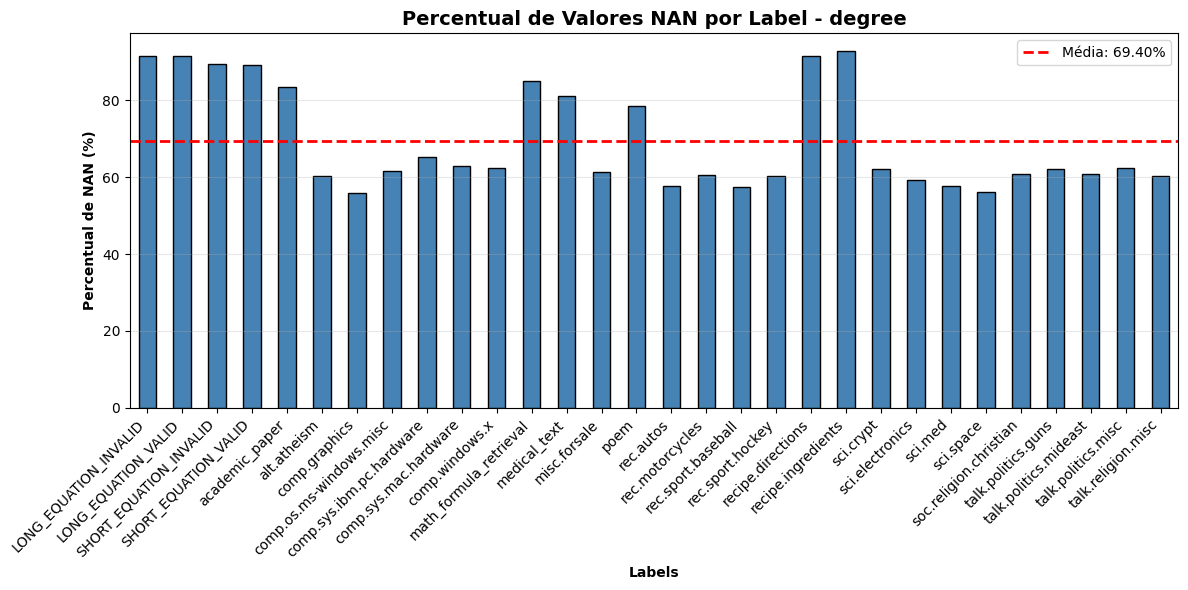

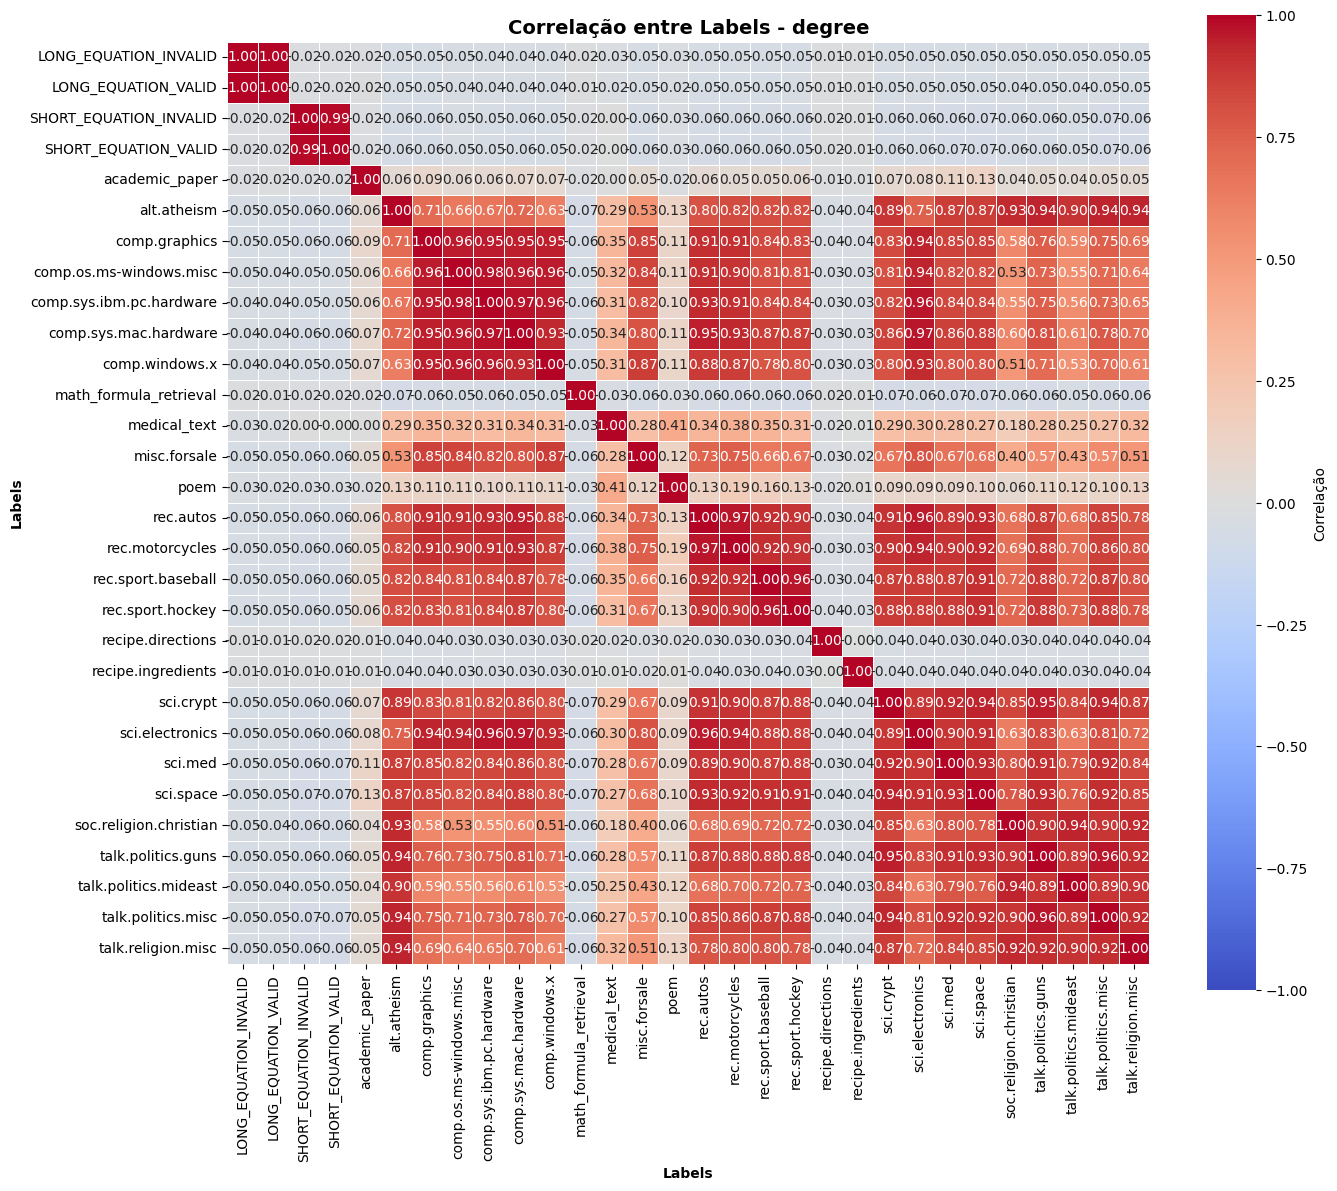

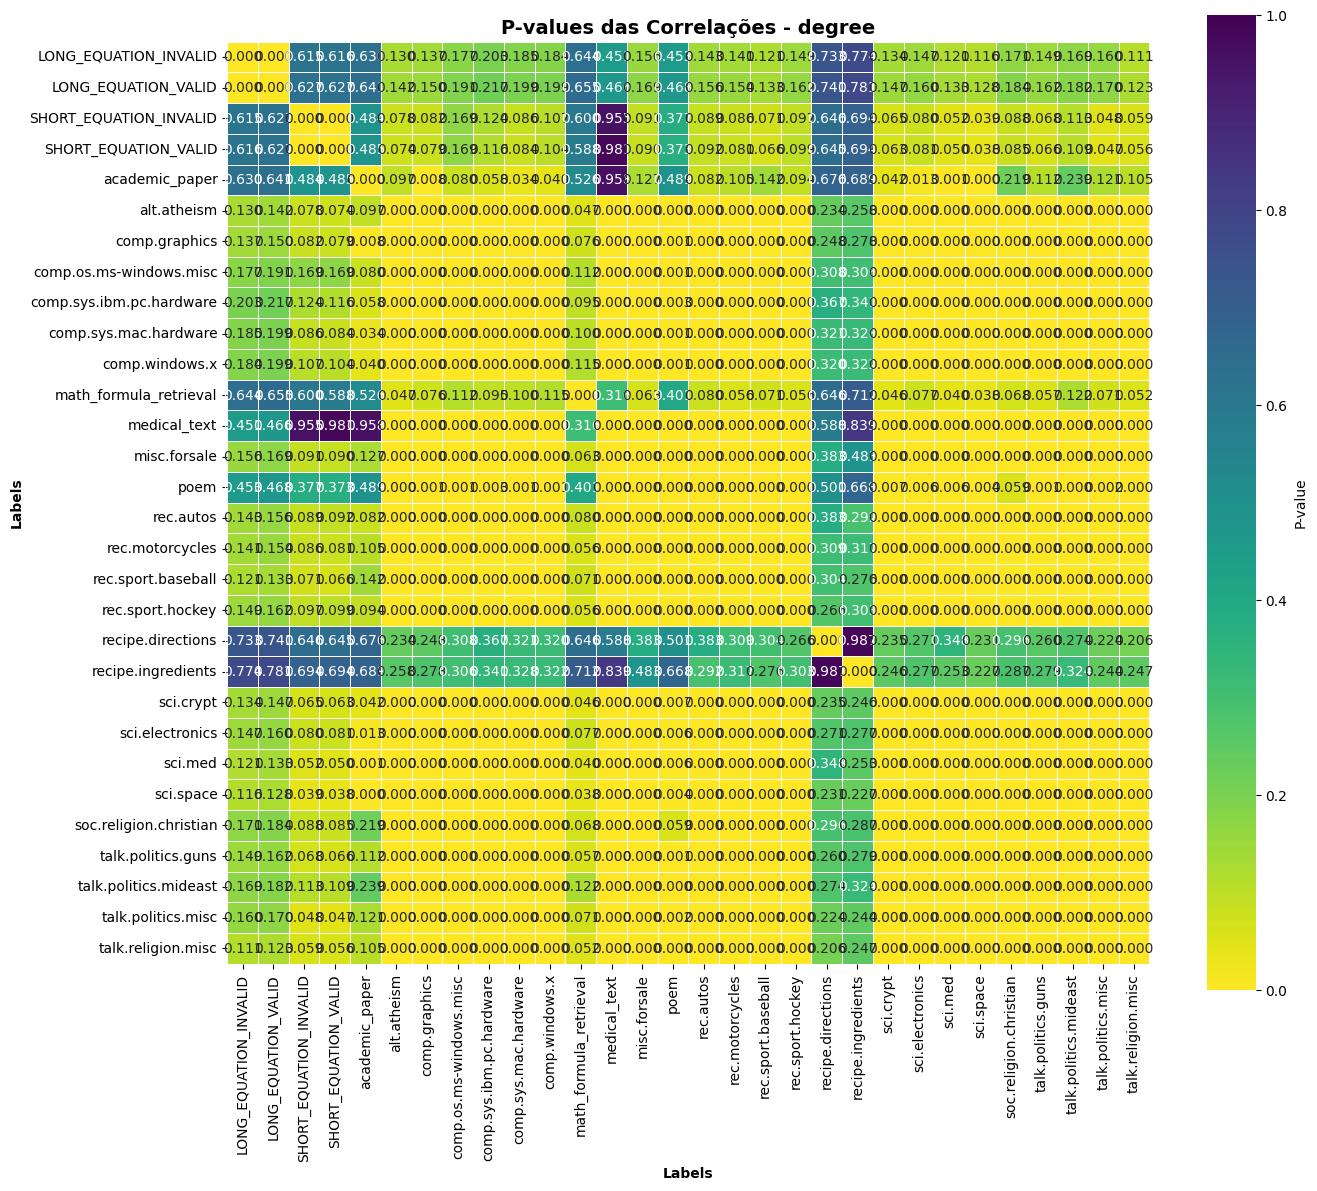


Top 10 pares com MAIOR correlação (degree):
                 label_1                  label_2  correlacao  p_value
   LONG_EQUATION_INVALID      LONG_EQUATION_VALID    0.996658      0.0
  SHORT_EQUATION_INVALID     SHORT_EQUATION_VALID    0.988042      0.0
 comp.os.ms-windows.misc comp.sys.ibm.pc.hardware    0.975485      0.0
comp.sys.ibm.pc.hardware    comp.sys.mac.hardware    0.970404      0.0
               rec.autos          rec.motorcycles    0.967095      0.0
   comp.sys.mac.hardware          sci.electronics    0.967085      0.0
comp.sys.ibm.pc.hardware          sci.electronics    0.963019      0.0
      rec.sport.baseball         rec.sport.hockey    0.962314      0.0
      talk.politics.guns       talk.politics.misc    0.961534      0.0
               rec.autos          sci.electronics    0.958955      0.0

Top 10 pares com MENOR correlação (degree):
               label_1                label_2  correlacao  p_value
math_formula_retrieval     talk.religion.misc   -0.064821 0.05

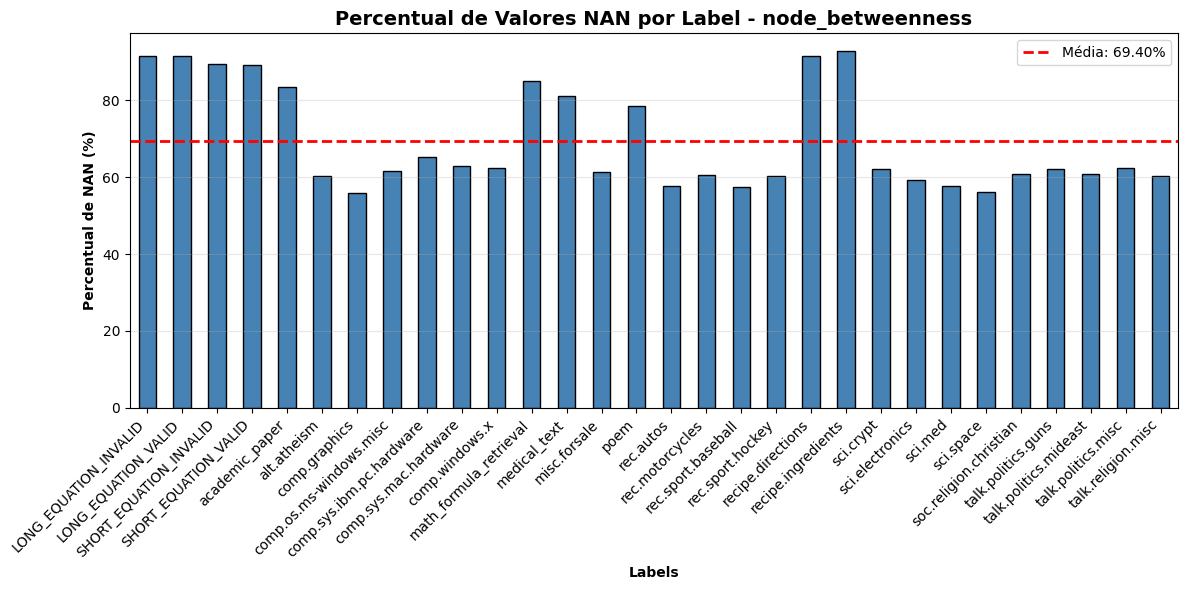

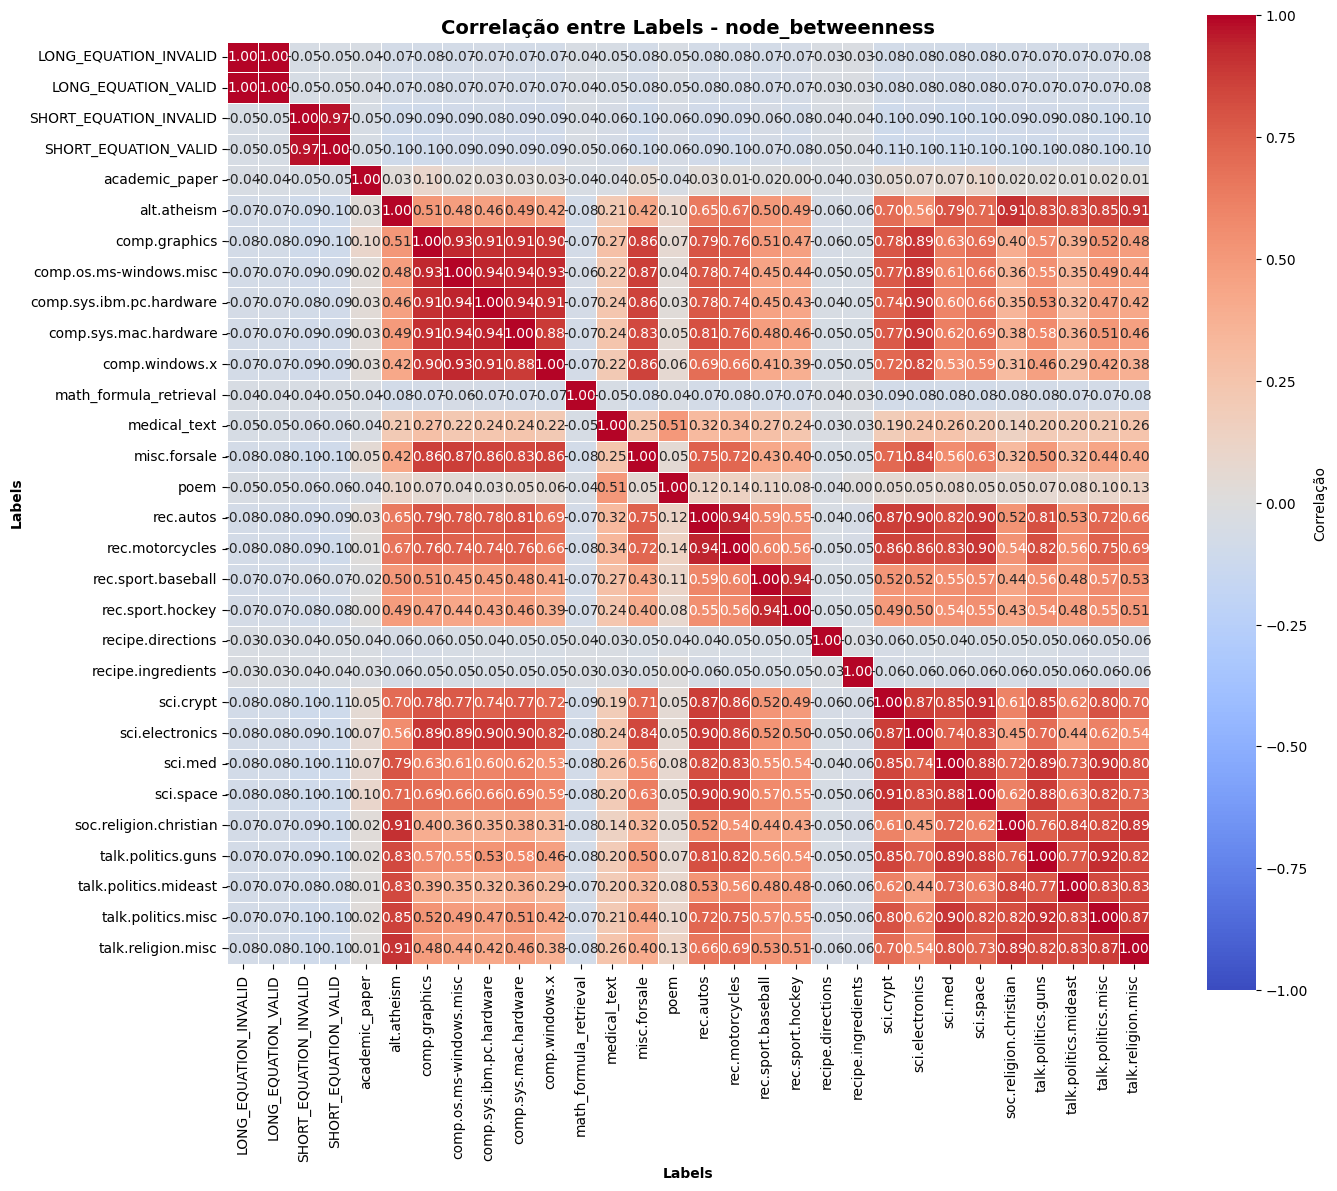

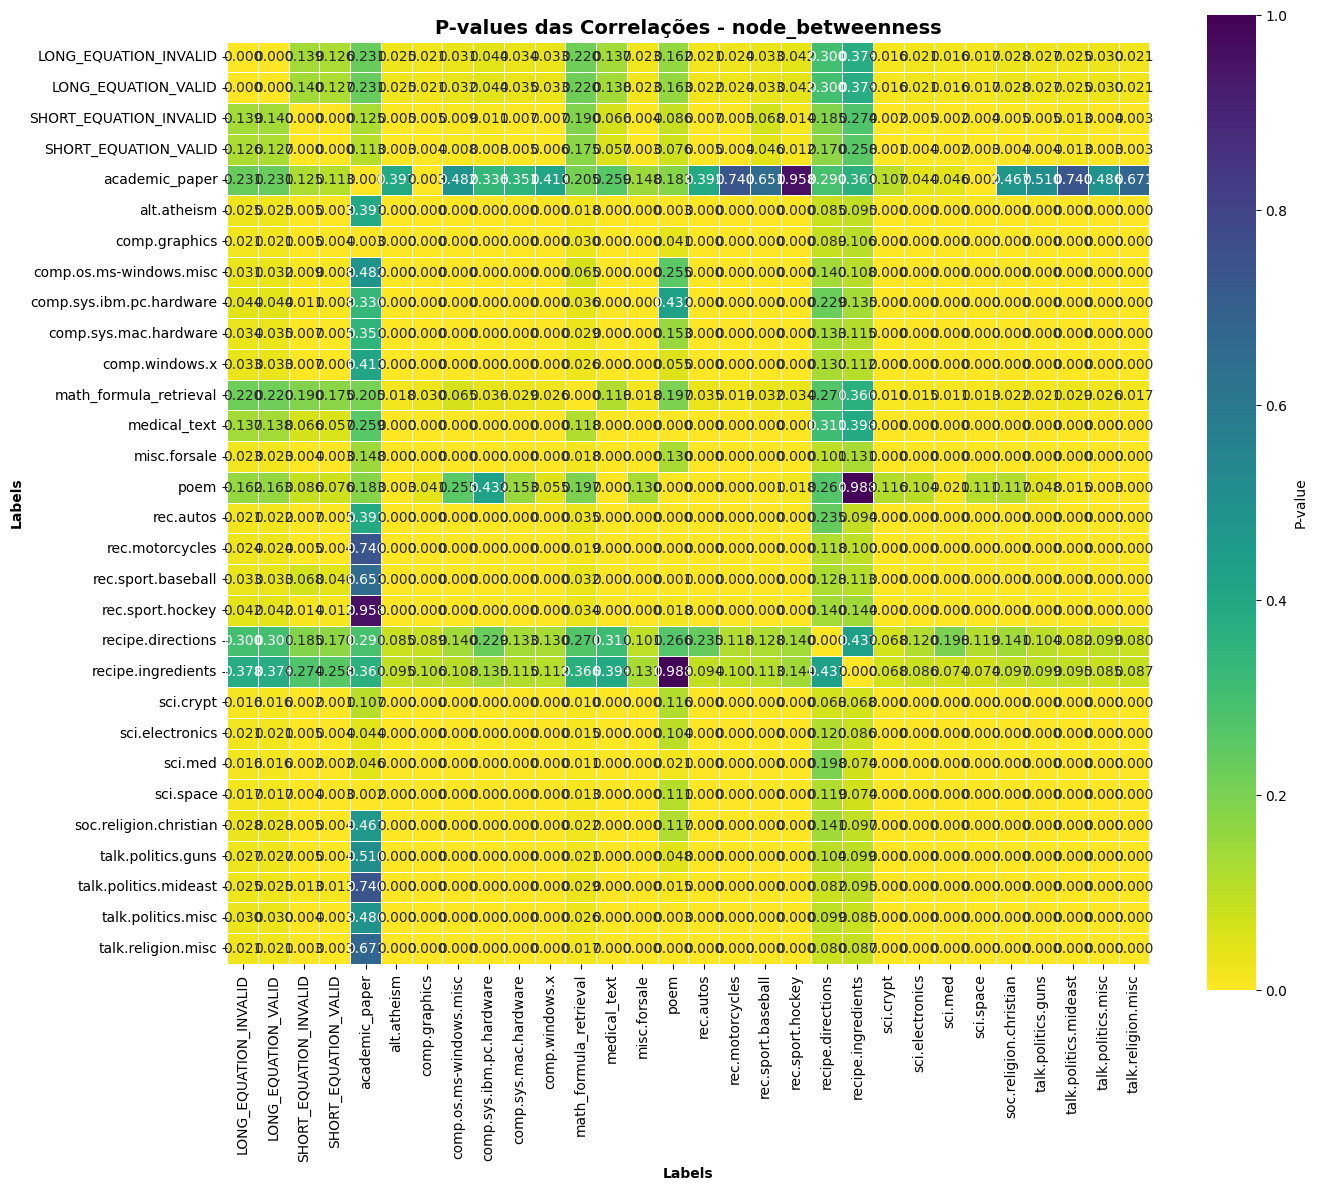


Top 10 pares com MAIOR correlação (node_betweenness):
                 label_1                  label_2  correlacao  p_value
   LONG_EQUATION_INVALID      LONG_EQUATION_VALID    0.996836      0.0
  SHORT_EQUATION_INVALID     SHORT_EQUATION_VALID    0.974084      0.0
 comp.os.ms-windows.misc comp.sys.ibm.pc.hardware    0.944652      0.0
comp.sys.ibm.pc.hardware    comp.sys.mac.hardware    0.944308      0.0
               rec.autos          rec.motorcycles    0.941416      0.0
 comp.os.ms-windows.misc    comp.sys.mac.hardware    0.937014      0.0
      rec.sport.baseball         rec.sport.hockey    0.935310      0.0
 comp.os.ms-windows.misc           comp.windows.x    0.932189      0.0
           comp.graphics  comp.os.ms-windows.misc    0.930829      0.0
      talk.politics.guns       talk.politics.misc    0.915072      0.0

Top 10 pares com MENOR correlação (node_betweenness):
               label_1            label_2  correlacao  p_value
SHORT_EQUATION_INVALID talk.religion.misc   -0

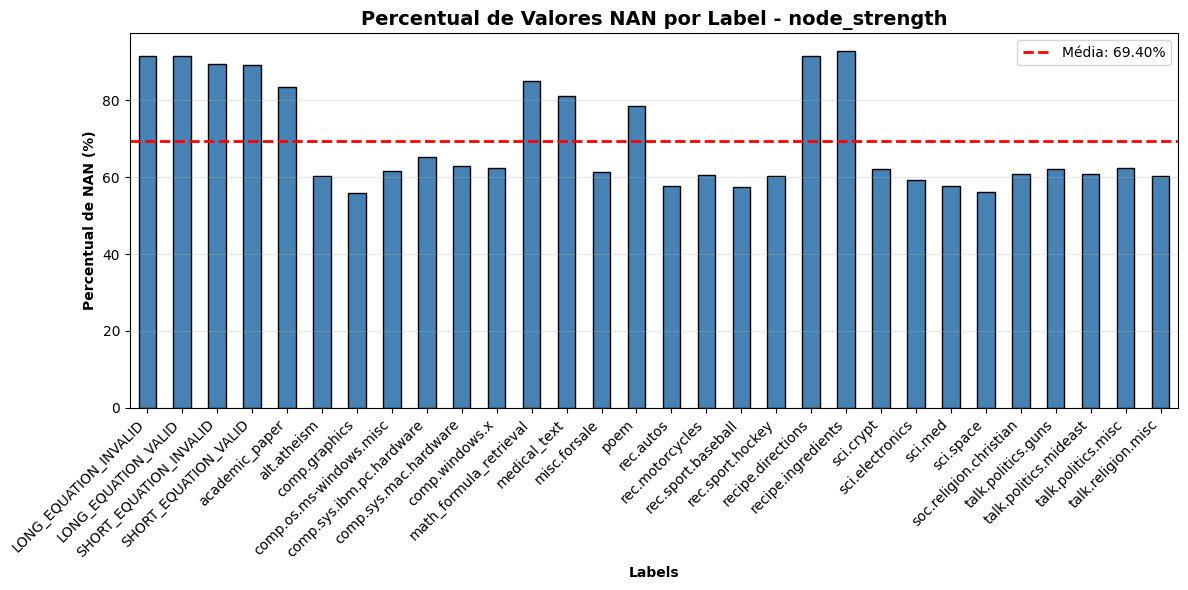

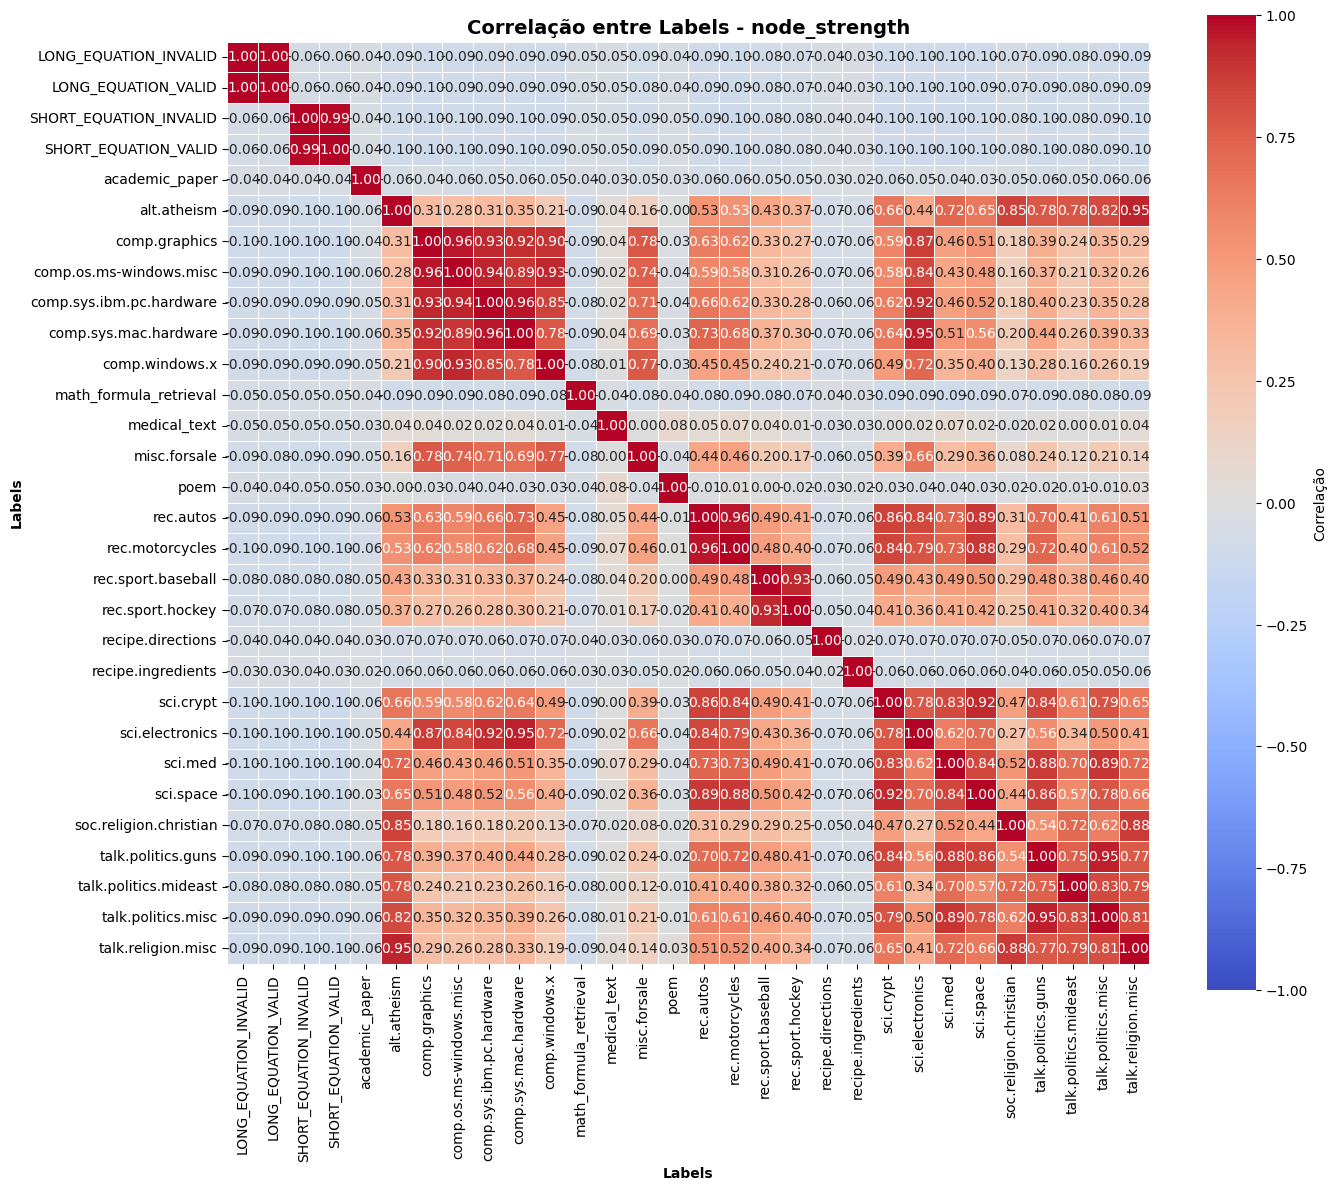

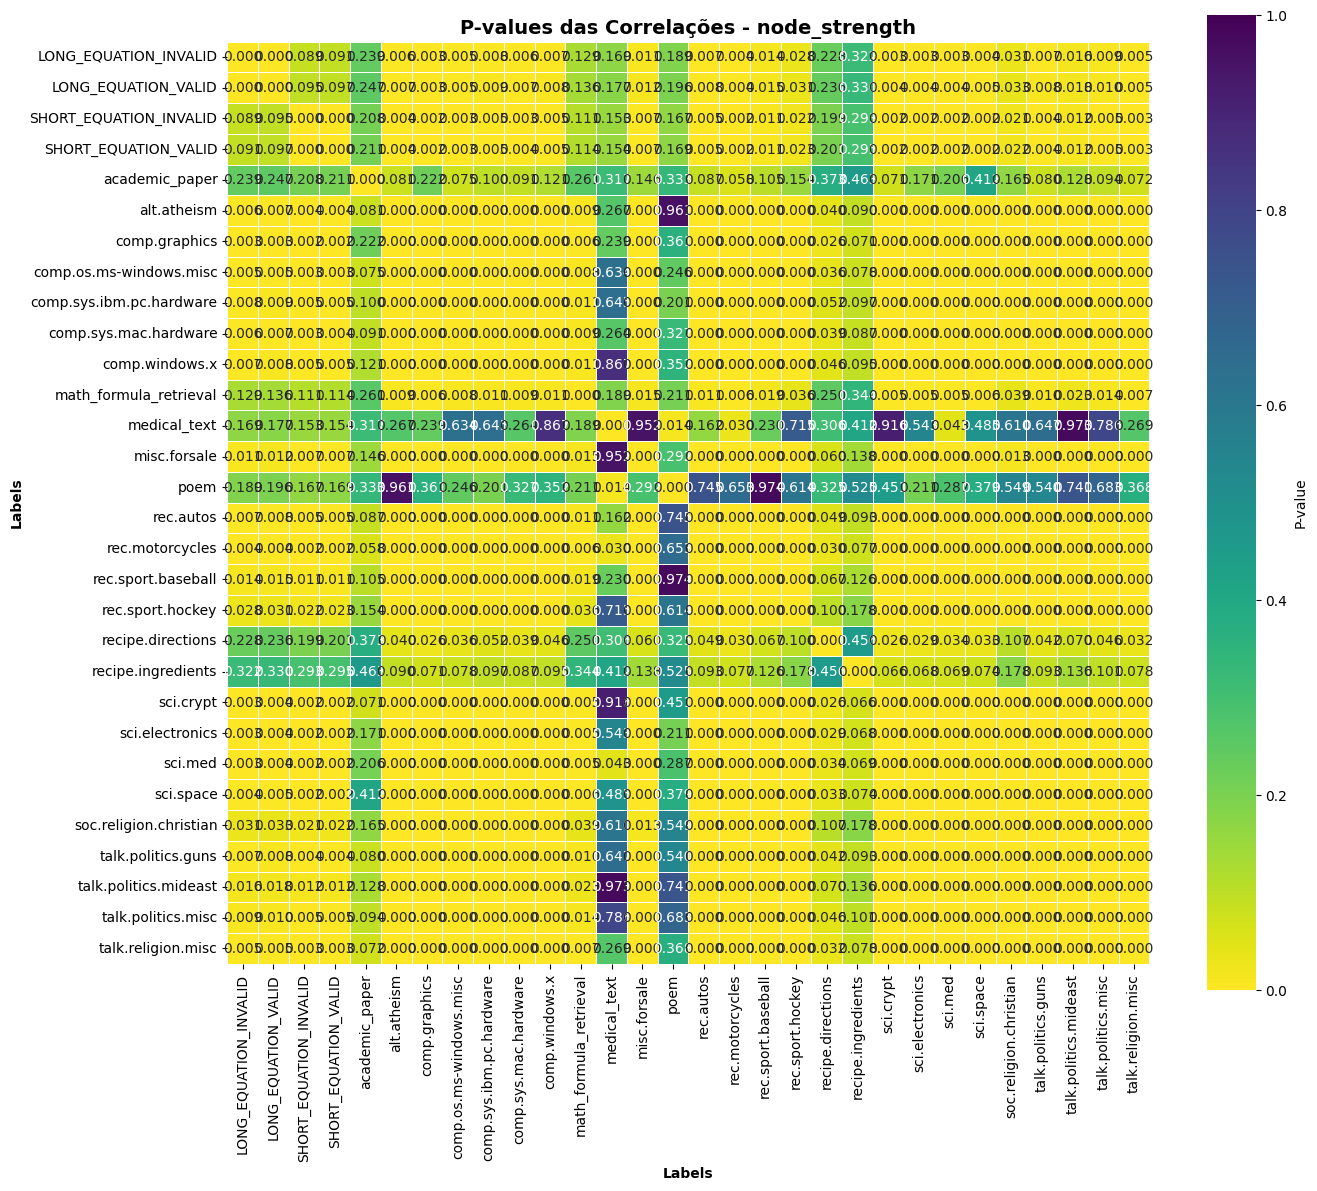


Top 10 pares com MAIOR correlação (node_strength):
                 label_1                  label_2  correlacao  p_value
   LONG_EQUATION_INVALID      LONG_EQUATION_VALID    0.996513      0.0
  SHORT_EQUATION_INVALID     SHORT_EQUATION_VALID    0.986800      0.0
comp.sys.ibm.pc.hardware    comp.sys.mac.hardware    0.964965      0.0
               rec.autos          rec.motorcycles    0.964428      0.0
           comp.graphics  comp.os.ms-windows.misc    0.964328      0.0
      talk.politics.guns       talk.politics.misc    0.953034      0.0
   comp.sys.mac.hardware          sci.electronics    0.951874      0.0
             alt.atheism       talk.religion.misc    0.945085      0.0
 comp.os.ms-windows.misc comp.sys.ibm.pc.hardware    0.943810      0.0
 comp.os.ms-windows.misc           comp.windows.x    0.932556      0.0

Top 10 pares com MENOR correlação (node_strength):
               label_1         label_2  correlacao  p_value
SHORT_EQUATION_INVALID       sci.space   -0.101360 0.00

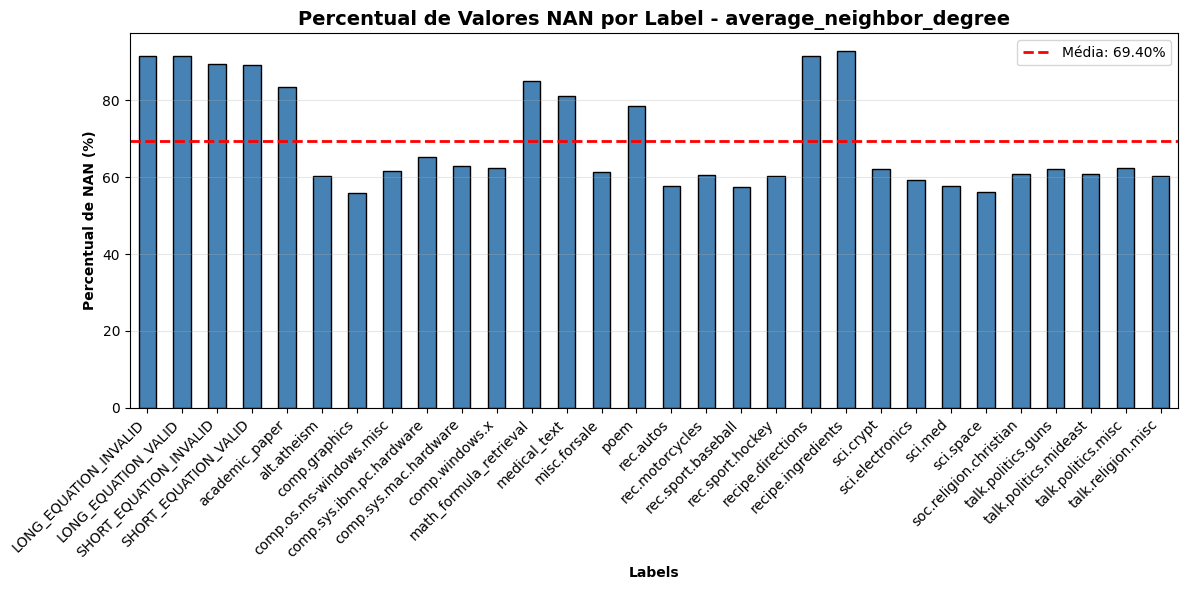

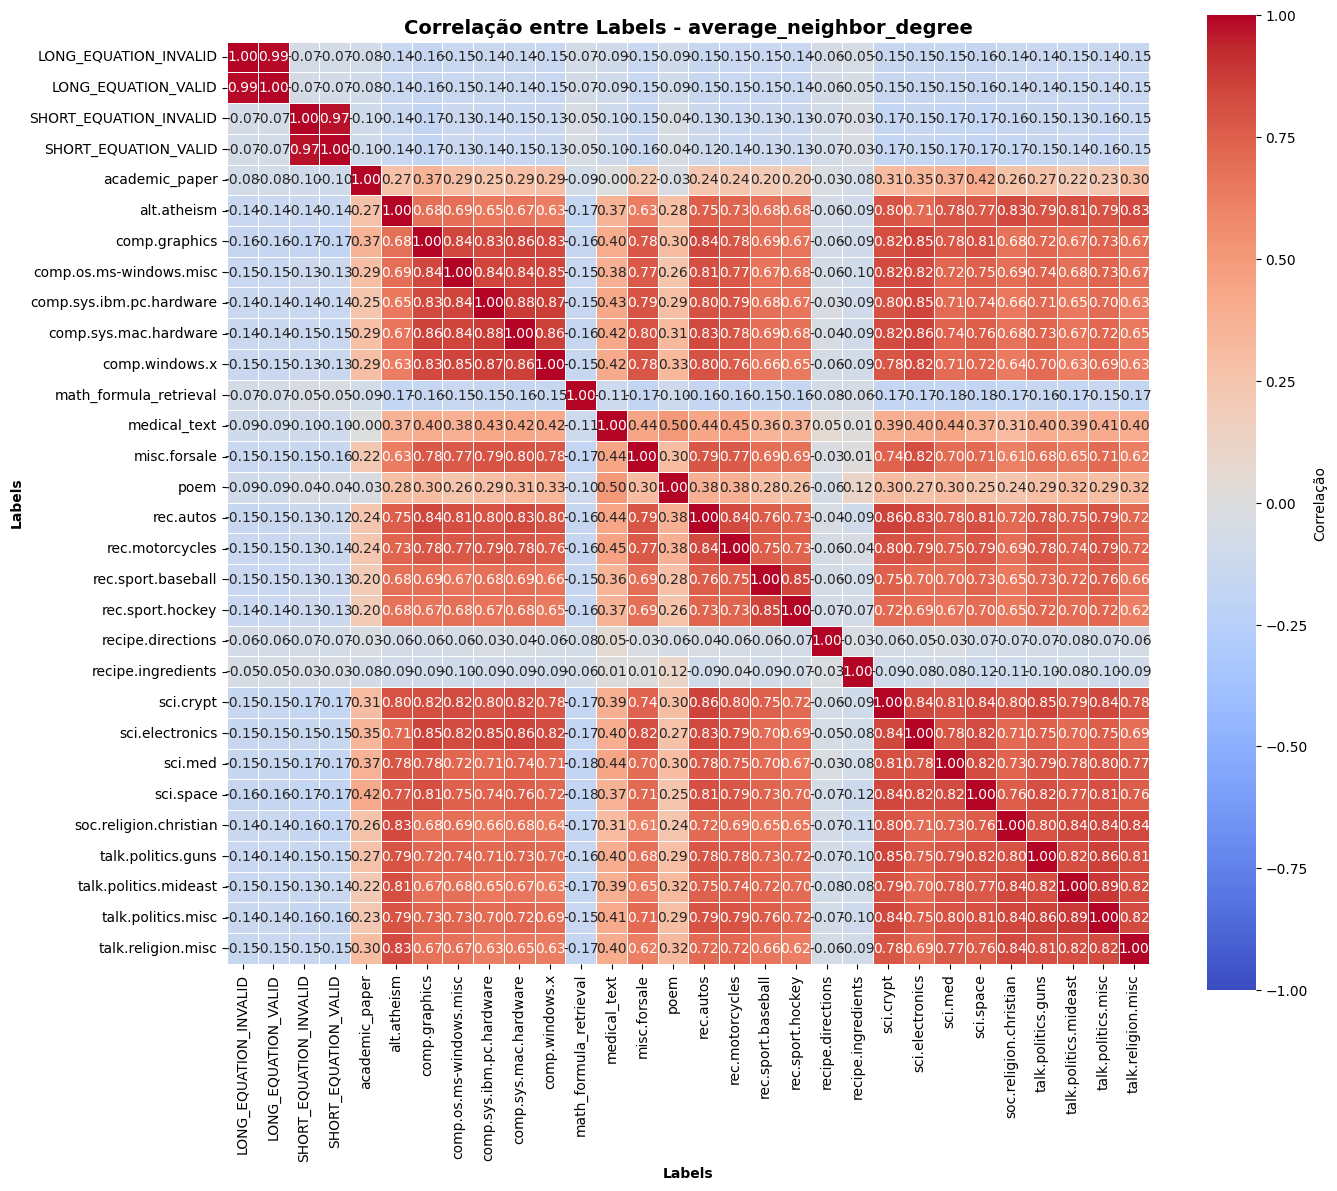

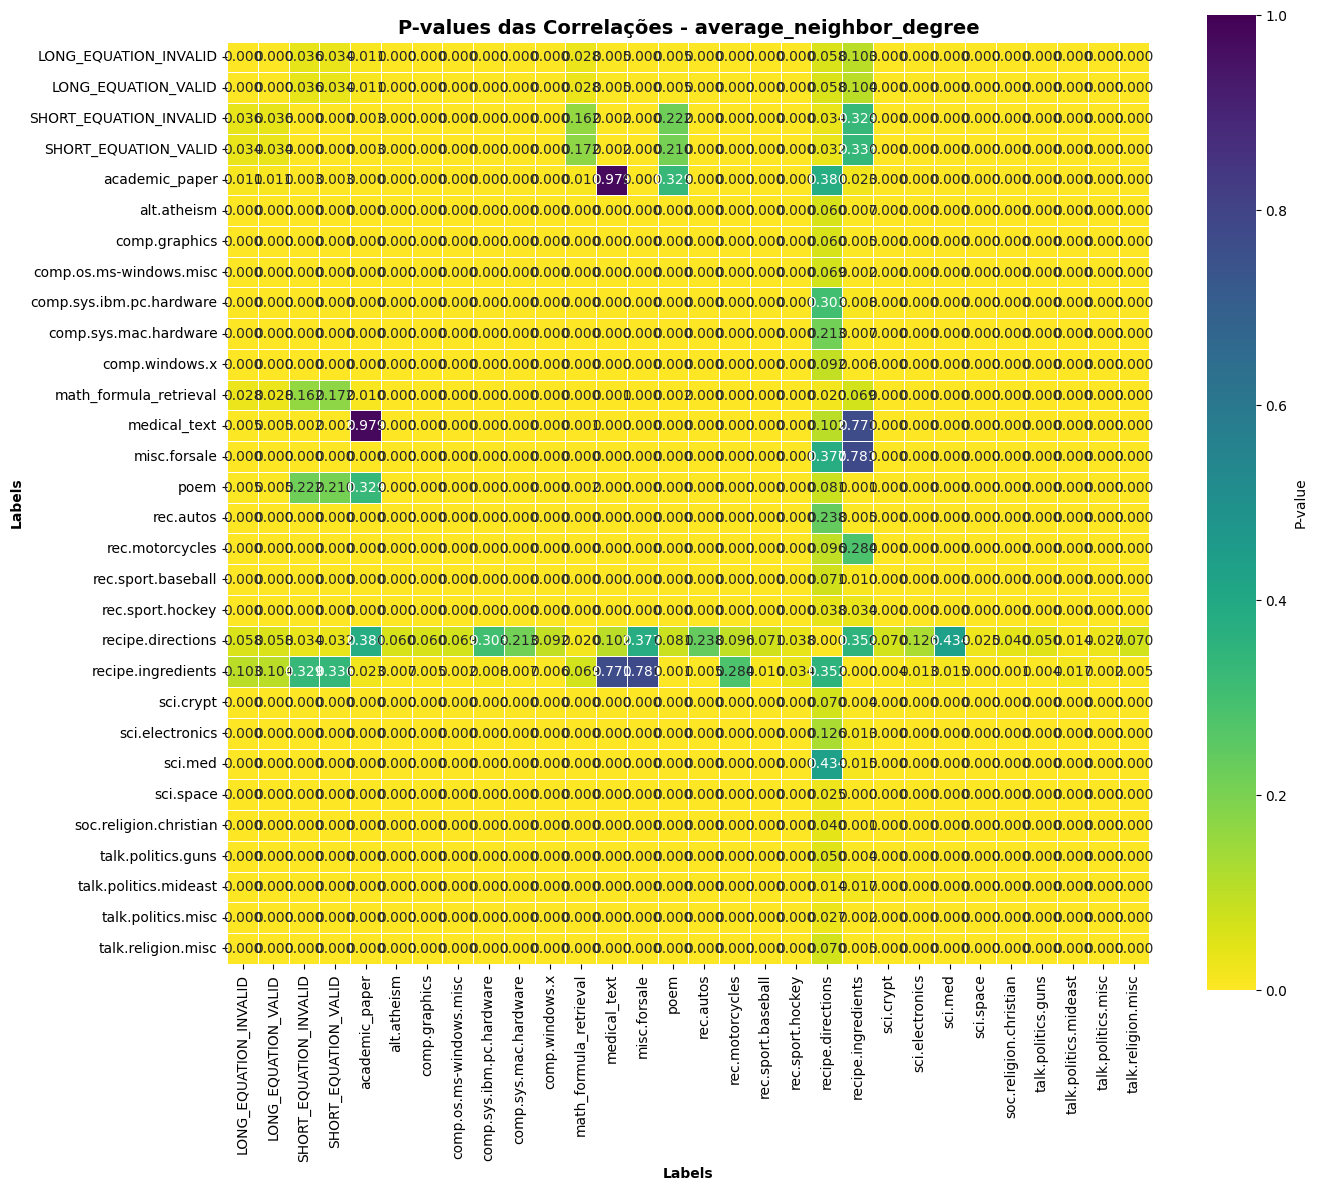


Top 10 pares com MAIOR correlação (average_neighbor_degree):
                 label_1               label_2  correlacao       p_value
   LONG_EQUATION_INVALID   LONG_EQUATION_VALID    0.991153  0.000000e+00
  SHORT_EQUATION_INVALID  SHORT_EQUATION_VALID    0.971392  0.000000e+00
   talk.politics.mideast    talk.politics.misc    0.887004 6.157527e-304
comp.sys.ibm.pc.hardware comp.sys.mac.hardware    0.879265 8.367374e-292
comp.sys.ibm.pc.hardware        comp.windows.x    0.874018 4.834841e-284
      talk.politics.guns    talk.politics.misc    0.864642 5.275884e-271
   comp.sys.mac.hardware        comp.windows.x    0.864188 2.129733e-270
   comp.sys.mac.hardware       sci.electronics    0.856692 1.080651e-260
           comp.graphics comp.sys.mac.hardware    0.855573 2.722576e-259
               rec.autos             sci.crypt    0.855513 3.233144e-259

Top 10 pares com MENOR correlação (average_neighbor_degree):
               label_1         label_2  correlacao      p_value
math_form

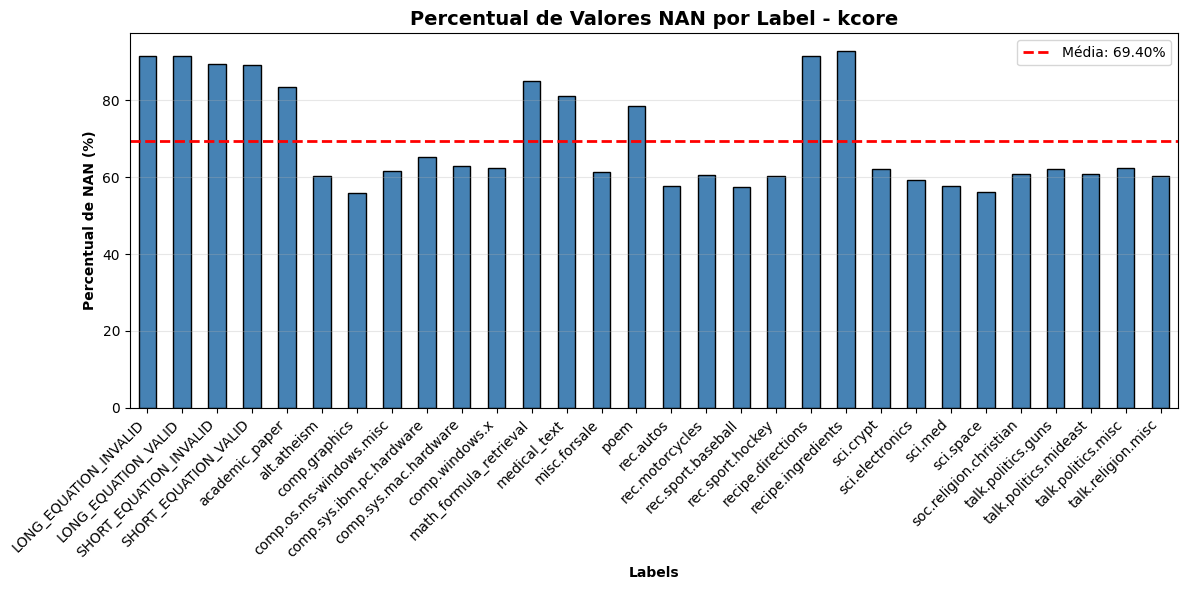

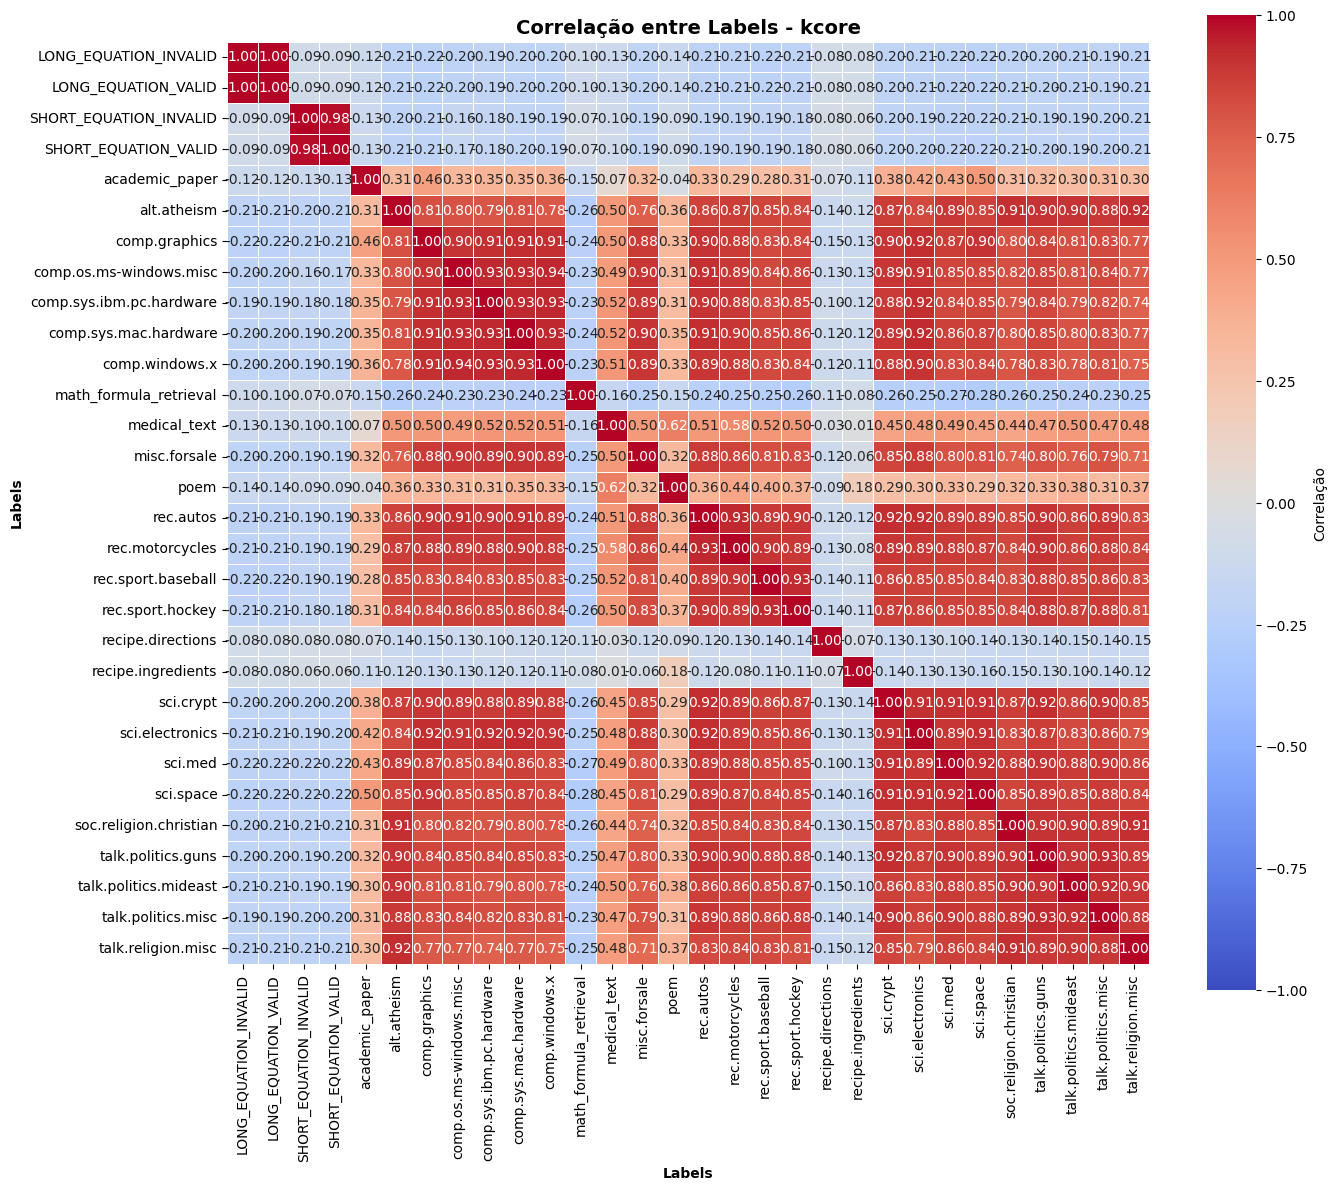

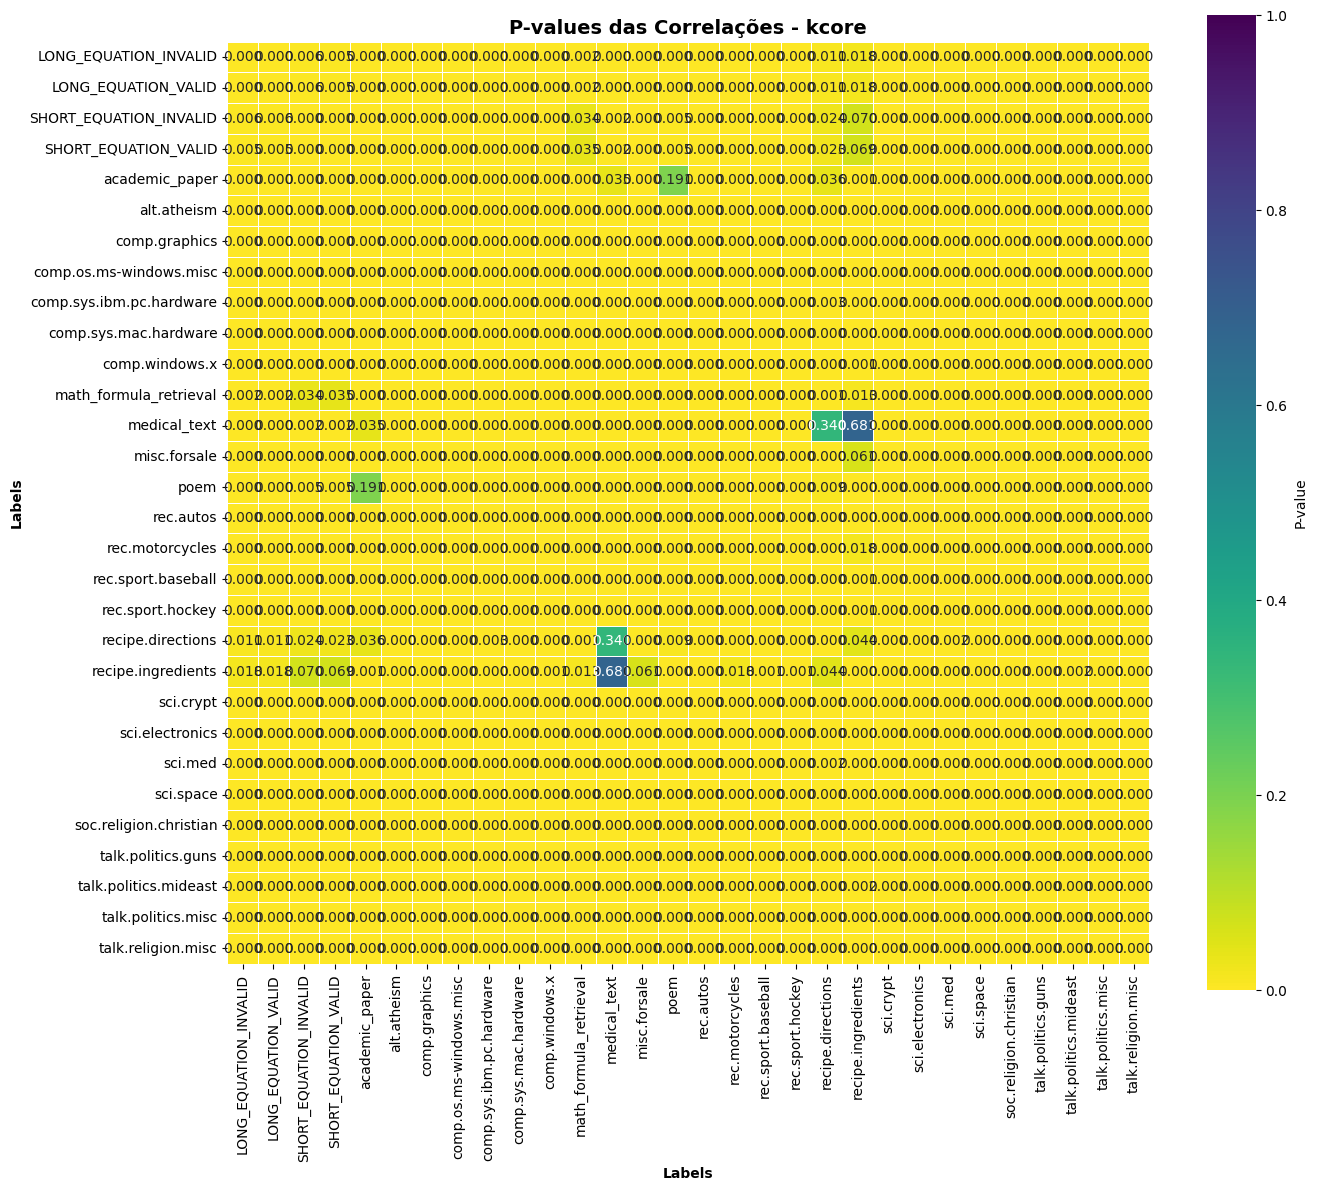


Top 10 pares com MAIOR correlação (kcore):
                 label_1                  label_2  correlacao  p_value
   LONG_EQUATION_INVALID      LONG_EQUATION_VALID    0.997176      0.0
  SHORT_EQUATION_INVALID     SHORT_EQUATION_VALID    0.982521      0.0
 comp.os.ms-windows.misc           comp.windows.x    0.937228      0.0
comp.sys.ibm.pc.hardware    comp.sys.mac.hardware    0.934189      0.0
comp.sys.ibm.pc.hardware           comp.windows.x    0.933956      0.0
 comp.os.ms-windows.misc comp.sys.ibm.pc.hardware    0.932839      0.0
   comp.sys.mac.hardware           comp.windows.x    0.931539      0.0
               rec.autos          rec.motorcycles    0.930163      0.0
 comp.os.ms-windows.misc    comp.sys.mac.hardware    0.929122      0.0
      rec.sport.baseball         rec.sport.hockey    0.927504      0.0

Top 10 pares com MENOR correlação (kcore):
               label_1                label_2  correlacao      p_value
math_formula_retrieval           misc.forsale   -0.248083 4.

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr



# Para cada métrica, calcular correlação e p-value entre as labels
for metric_name in available_metrics:

    df_metric_comparison = pd.read_csv(f'{PROCESSED_DATASET_PATH}/aggregate_nodes_{metric_name}_with_node.csv')
    
    # Remove the first layers (input layers) if they exist, as they can skew the correlation analysis
    df_metric_comparison = df_metric_comparison[~df_metric_comparison['node'].str.startswith('0_')]
    # Remover coluna 'node'
    df_metric_comparison.drop(columns=['node'], inplace=True)
    

    
    # ==========================================
    # GRÁFICO: QUANTIDADE DE VALORES NAN
    # ==========================================
    nan_counts = (df_metric_comparison.isnull()).sum()
    
    # Calculate percentage of NaNs
    nan_percentages = (nan_counts / len(df_metric_comparison) * 100)
    
    # Calculate mean percentage across all labels
    mean_percentage = nan_percentages.mean()
    
    plt.figure(figsize=(12, 6))
    bars = nan_percentages.plot(kind='bar', color='steelblue', edgecolor='black')
    
    # Add horizontal line for mean
    plt.axhline(y=mean_percentage, color='red', linestyle='--', linewidth=2, label=f'Média: {mean_percentage:.2f}%')
    
    plt.title(f'Percentual de Valores NAN por Label - {metric_name}', fontsize=14, fontweight='bold')
    plt.xlabel('Labels', fontweight='bold')
    plt.ylabel('Percentual de NAN (%)', fontweight='bold')
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()
    
    
    # Turn nan values in zeros (or you could choose to drop them, depending on your analysis needs)
    df_metric_comparison.fillna(0, inplace=True)
    
    # 1. Obter os nomes das colunas (labels)
    cols = df_metric_comparison.columns
    
    # 2. Matriz de Correlação
    correlation_matrix = df_metric_comparison.corr()
    
    # 3. Matriz de P-values (inicializada com zeros)
    p_values_matrix = pd.DataFrame(np.zeros((len(cols), len(cols))), columns=cols, index=cols)
    
    # Calcular os p-values par a par
    for col1 in cols:
        for col2 in cols:
            if col1 == col2:
                # O p-value de uma variável com ela mesma é 0.0 por convenção aqui
                p_values_matrix.loc[col1, col2] = 0.0 
            else:
                # Filtrar NaNs apenas para o par atual para evitar erros no scipy
                valid_data = df_metric_comparison[[col1, col2]].dropna()
                if len(valid_data) > 1:
                    # Verificar se há variância em ambas as colunas
                    if valid_data[col1].std() > 0 and valid_data[col2].std() > 0:
                        corr, p_val = pearsonr(valid_data[col1], valid_data[col2])
                        p_values_matrix.loc[col1, col2] = p_val
                    else:
                        # Se alguma coluna é constante, a correlação é indefinida
                        p_values_matrix.loc[col1, col2] = np.nan
                else:
                    p_values_matrix.loc[col1, col2] = np.nan

    # ==========================================
    # HEATMAP 1: CORRELAÇÃO
    # ==========================================
    plt.figure(figsize=(14, 12))
    sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, 
                vmin=-1, vmax=1, cbar_kws={'label': 'Correlação'}, 
                square=True, linewidths=0.5, cbar=True)
    plt.title(f'Correlação entre Labels - {metric_name}', fontsize=14, fontweight='bold')
    plt.xlabel('Labels', fontweight='bold')
    plt.ylabel('Labels', fontweight='bold')
    plt.tight_layout()
    plt.show()

    # ==========================================
    # HEATMAP 2: P-VALUES
    # ==========================================
    plt.figure(figsize=(14, 12))
    # 'viridis_r' destaca valores próximos a 0 (menores p-values = mais significativos)
    sns.heatmap(p_values_matrix, annot=True, fmt='.3f', cmap='viridis_r', 
                vmin=0, vmax=1, cbar_kws={'label': 'P-value'}, 
                square=True, linewidths=0.5, cbar=True)
    plt.title(f'P-values das Correlações - {metric_name}', fontsize=14, fontweight='bold')
    plt.xlabel('Labels', fontweight='bold')
    plt.ylabel('Labels', fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    # ==========================================
    # RANKING DE CORRELAÇÕES
    # ==========================================
    corr_values = []
    # Usar cols para garantir alinhamento exato
    for i in range(len(cols)):
        for j in range(i+1, len(cols)):
            col1 = cols[i]
            col2 = cols[j]
            corr_values.append({
                'label_1': col1,
                'label_2': col2,
                'correlacao': correlation_matrix.iloc[i, j],
                'p_value': p_values_matrix.iloc[i, j] # Adicionado o p-value ao relatório!
            })
    
    df_corr = pd.DataFrame(corr_values).sort_values('correlacao', ascending=False)
    
    print(f"\nTop 10 pares com MAIOR correlação ({metric_name}):")
    print(df_corr.head(10).to_string(index=False))
    
    print(f"\nTop 10 pares com MENOR correlação ({metric_name}):")
    print(df_corr.tail(10).to_string(index=False))

# Shared Regions

In [ ]:

dataset = load_from_disk(STRUCTURED_DATASET_PATH)
class_names = dataset.features["label"].names


for label in [*class_names,  "total"]:
    print(f"\nProcessando: {label}")
    
    # Carregar grafo
    graph_path = f"{GRAPH_PATH}/g_{label}.gexf"

ANALISANDO REGIÕES COMPARTILHADAS ENTRE LABELS
✓ LONG_EQUATION_INVALID: 222 nós
✓ LONG_EQUATION_VALID: 227 nós
✓ SHORT_EQUATION_INVALID: 235 nós
✓ SHORT_EQUATION_VALID: 245 nós
✓ academic_paper: 317 nós
✓ alt.atheism: 512 nós
✓ comp.graphics: 563 nós
✓ comp.os.ms-windows.misc: 513 nós
✓ comp.sys.ibm.pc.hardware: 484 nós
✓ comp.sys.mac.hardware: 504 nós
✓ comp.windows.x: 502 nós
✓ math_formula_retrieval: 302 nós
✓ medical_text: 333 nós
✓ misc.forsale: 510 nós
✓ poem: 358 nós
✓ rec.autos: 538 nós
✓ rec.motorcycles: 524 nós
✓ rec.sport.baseball: 546 nós
✓ rec.sport.hockey: 523 nós
✓ recipe.directions: 238 nós
✓ recipe.ingredients: 235 nós
✓ sci.crypt: 503 nós
✓ sci.electronics: 530 nós
✓ sci.med: 549 nós
✓ sci.space: 561 nós
✓ soc.religion.christian: 520 nós
✓ talk.politics.guns: 512 nós
✓ talk.politics.mideast: 522 nós
✓ talk.politics.misc: 499 nós
✓ talk.religion.misc: 503 nós

Regiões compartilhadas (valores absolutos):
       Shared Regions  Total Label1  Total Label2
count      435.0

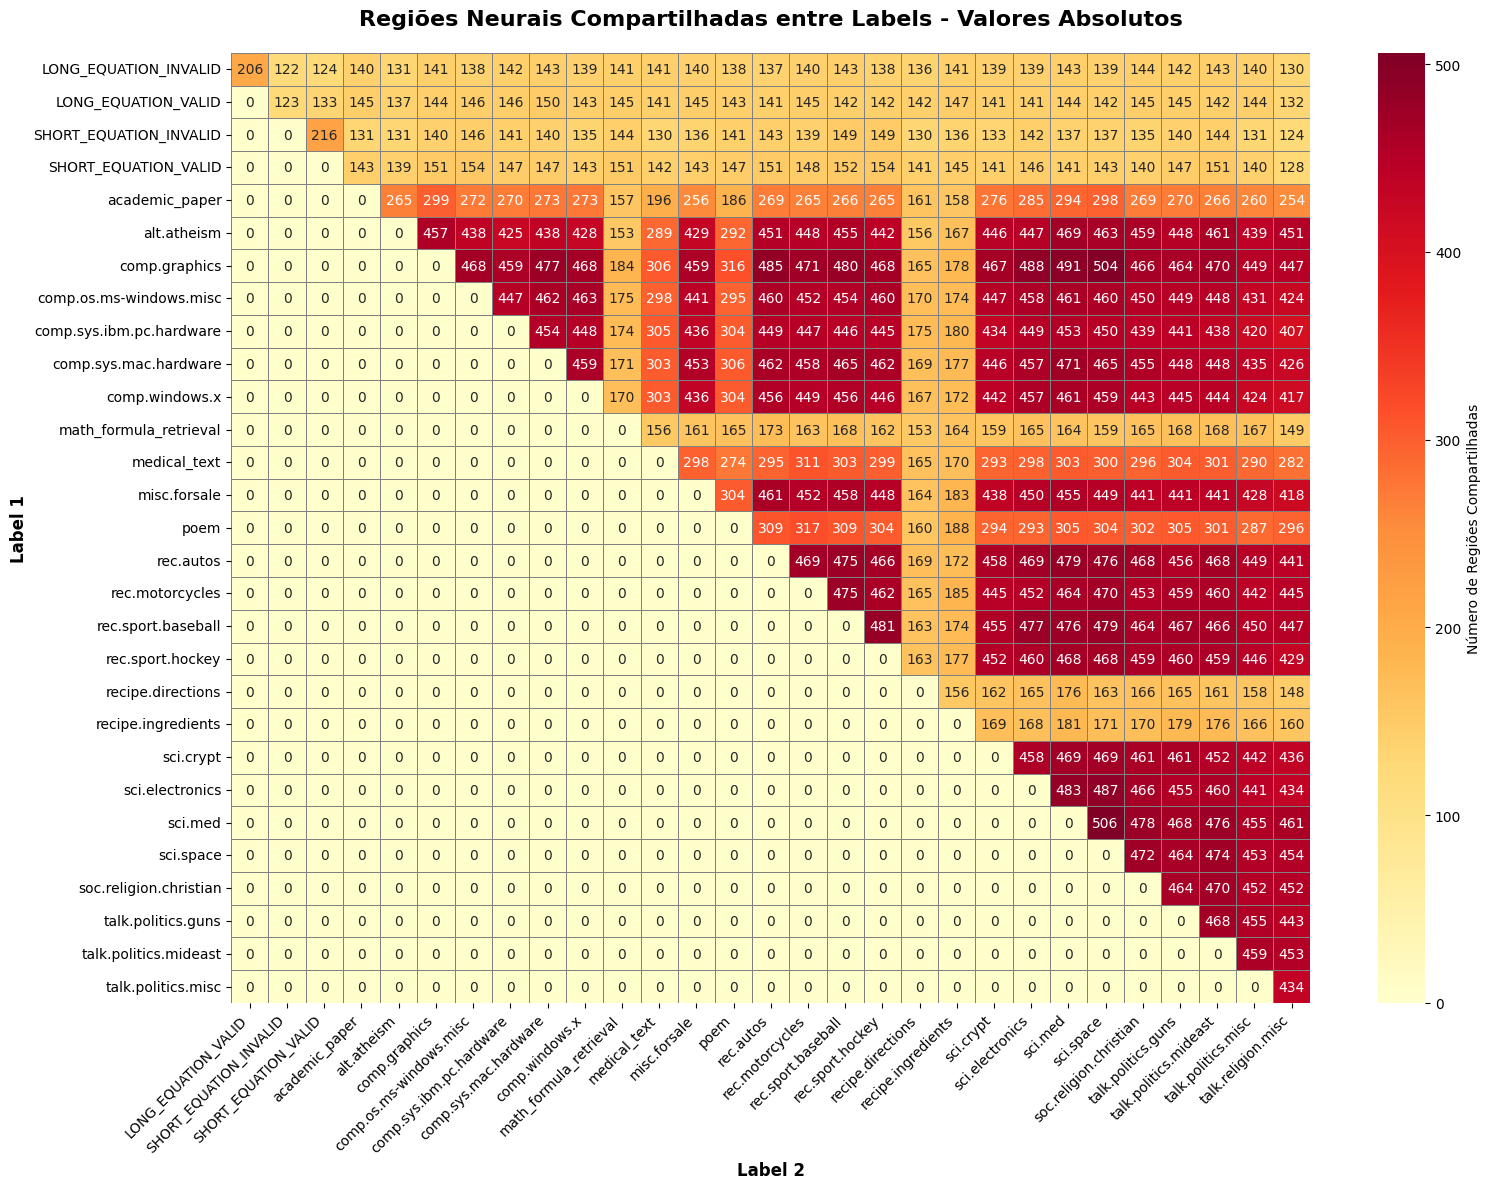

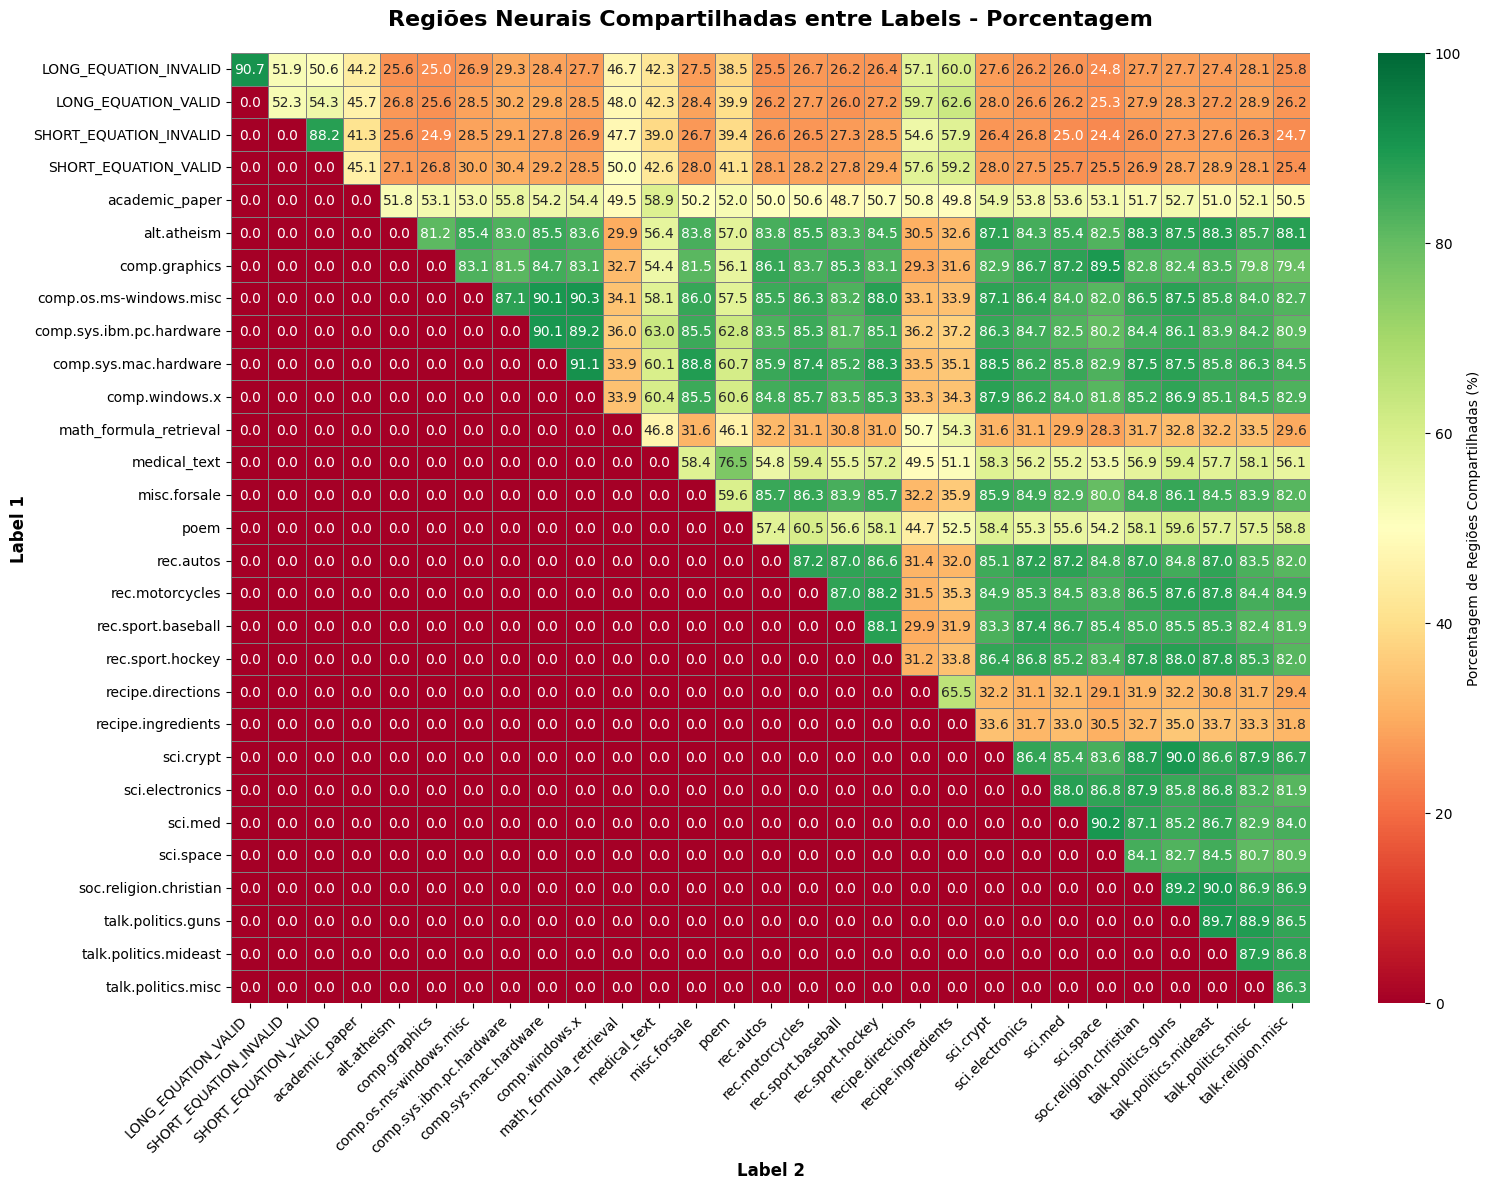

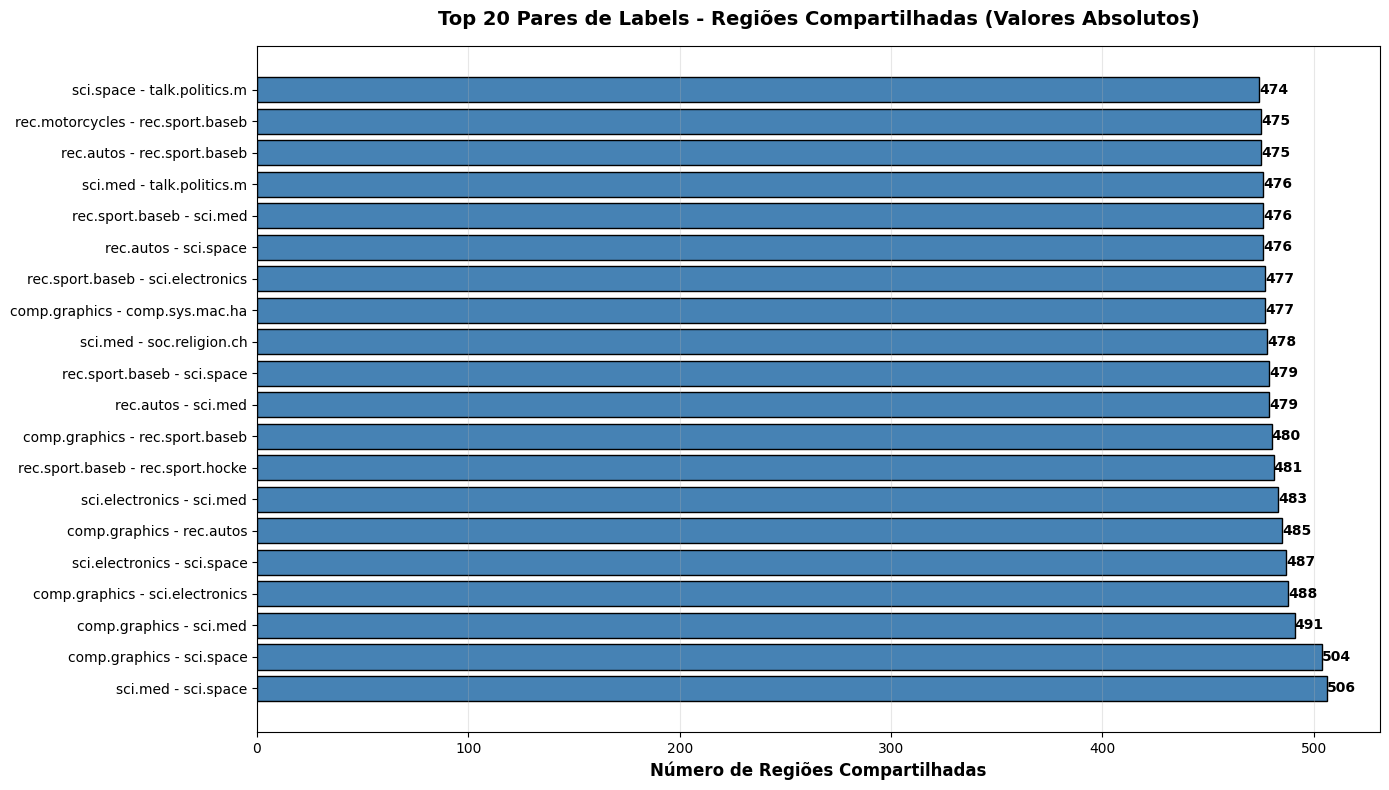

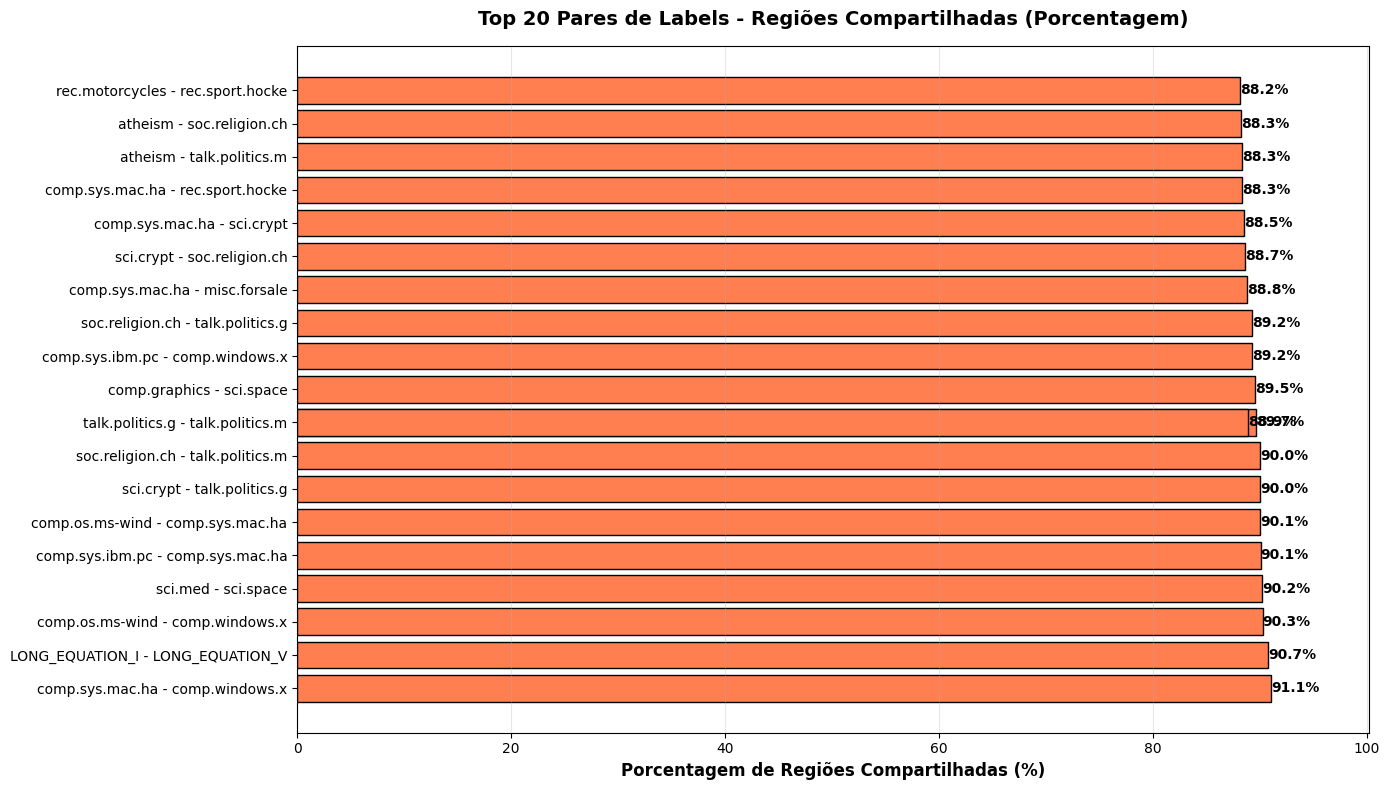


RESUMO ESTATÍSTICO

Valores Absolutos:
  Média: 304.06 regiões
  Mediana: 298.00 regiões
  Mínimo: 122 regiões
  Máximo: 506 regiões

Porcentagem:
  Média: 59.89%
  Mediana: 58.08%
  Mínimo: 24.42%
  Máximo: 91.07%

✓ Análise concluída!


In [9]:
import networkx as nx
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Carregar dataset para obter nomes das classes
dataset = load_from_disk(STRUCTURED_DATASET_PATH)
class_names = dataset.features["label"].names

print("=" * 70)
print("ANALISANDO REGIÕES COMPARTILHADAS ENTRE LABELS")
print("=" * 70)

# Dicionário para armazenar os nós de cada label
label_nodes = {}

# Carregar nós de cada label
for label in class_names:
    graph_path = f"{GRAPH_PATH}/g_{label}.gexf"
    try:
        G = nx.read_gexf(graph_path)
        label_nodes[label] = set(G.nodes())
        print(f"✓ {label}: {len(G.nodes())} nós")
    except Exception as e:
        print(f"✗ Erro ao carregar {label}: {e}")

# Calcular regiões compartilhadas entre pares de labels
shared_regions_absolute = []
shared_regions_percentage = []

labels_list = list(label_nodes.keys())

for i, label1 in enumerate(labels_list):
    for label2 in labels_list[i+1:]:
        nodes1 = label_nodes[label1]
        nodes2 = label_nodes[label2]
        
        # Regiões compartilhadas
        shared = nodes1.intersection(nodes2)
        num_shared = len(shared)
        
        # Total de nós únicos
        total_unique = len(nodes1.union(nodes2))
        
        # Percentagem baseada no máximo entre os dois
        max_nodes = max(len(nodes1), len(nodes2))
        percentage = (num_shared / max_nodes * 100) if max_nodes > 0 else 0
        
        shared_regions_absolute.append({
            'Label 1': label1,
            'Label 2': label2,
            'Shared Regions': num_shared,
            'Total Label1': len(nodes1),
            'Total Label2': len(nodes2),
        })
        
        shared_regions_percentage.append({
            'Label 1': label1,
            'Label 2': label2,
            'Shared Regions %': percentage,
        })

# Criar DataFrames
df_absolute = pd.DataFrame(shared_regions_absolute)
df_percentage = pd.DataFrame(shared_regions_percentage)

# Criar pivot tables para visualização
pivot_absolute = pd.pivot_table(
    df_absolute, 
    values='Shared Regions', 
    index='Label 1', 
    columns='Label 2',
    fill_value=0
)

pivot_percentage = pd.pivot_table(
    df_percentage,
    values='Shared Regions %',
    index='Label 1',
    columns='Label 2',
    fill_value=0
)

print("\nRegiões compartilhadas (valores absolutos):")
print(df_absolute.describe())

print("\nRegiões compartilhadas (porcentagem):")
print(df_percentage.describe())

# ==========================================
# PLOT 1: VALORES ABSOLUTOS (Heatmap)
# ==========================================
plt.figure(figsize=(16, 12))
sns.heatmap(pivot_absolute, annot=True, fmt='.0f', cmap='YlOrRd', 
            cbar_kws={'label': 'Número de Regiões Compartilhadas'},
            linewidths=0.5, linecolor='gray')
plt.title('Regiões Neurais Compartilhadas entre Labels - Valores Absolutos', 
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Label 2', fontweight='bold', fontsize=12)
plt.ylabel('Label 1', fontweight='bold', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('./shared_regions_absolute.png', dpi=300, bbox_inches='tight')
plt.show()

# ==========================================
# PLOT 2: PORCENTAGEM (Heatmap)
# ==========================================
plt.figure(figsize=(16, 12))
sns.heatmap(pivot_percentage, annot=True, fmt='.1f', cmap='RdYlGn', 
            cbar_kws={'label': 'Porcentagem de Regiões Compartilhadas (%)'},
            linewidths=0.5, linecolor='gray', vmin=0, vmax=100)
plt.title('Regiões Neurais Compartilhadas entre Labels - Porcentagem', 
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Label 2', fontweight='bold', fontsize=12)
plt.ylabel('Label 1', fontweight='bold', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('./shared_regions_percentage.png', dpi=300, bbox_inches='tight')
plt.show()

# ==========================================
# PLOT 3: Distribuição em Barras (Valores Absolutos)
# ==========================================
# Top 20 pares com mais regiões compartilhadas
df_top = df_absolute.nlargest(20, 'Shared Regions').copy()
df_top['Pair'] = df_top['Label 1'].str.replace('alt.', '', regex=False).str[:15] + ' - ' + \
                 df_top['Label 2'].str.replace('alt.', '', regex=False).str[:15]

plt.figure(figsize=(14, 8))
bars = plt.barh(df_top['Pair'], df_top['Shared Regions'], color='steelblue', edgecolor='black')
plt.xlabel('Número de Regiões Compartilhadas', fontweight='bold', fontsize=12)
plt.title('Top 20 Pares de Labels - Regiões Compartilhadas (Valores Absolutos)', 
          fontsize=14, fontweight='bold', pad=15)
plt.grid(axis='x', alpha=0.3)

# Adicionar valores nas barras
for i, bar in enumerate(bars):
    width = bar.get_width()
    plt.text(width, bar.get_y() + bar.get_height()/2, f'{int(width)}',
            ha='left', va='center', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.savefig('./shared_regions_top20_absolute.png', dpi=300, bbox_inches='tight')
plt.show()

# ==========================================
# PLOT 4: Distribuição em Barras (Porcentagem)
# ==========================================
# Top 20 pares com maior porcentagem de regiões compartilhadas
df_top_pct = df_percentage.nlargest(20, 'Shared Regions %').copy()
df_top_pct['Pair'] = df_top_pct['Label 1'].str.replace('alt.', '', regex=False).str[:15] + ' - ' + \
                     df_top_pct['Label 2'].str.replace('alt.', '', regex=False).str[:15]

plt.figure(figsize=(14, 8))
bars = plt.barh(df_top_pct['Pair'], df_top_pct['Shared Regions %'], color='coral', edgecolor='black')
plt.xlabel('Porcentagem de Regiões Compartilhadas (%)', fontweight='bold', fontsize=12)
plt.title('Top 20 Pares de Labels - Regiões Compartilhadas (Porcentagem)', 
          fontsize=14, fontweight='bold', pad=15)
plt.xlim(0, max(df_top_pct['Shared Regions %']) * 1.1)
plt.grid(axis='x', alpha=0.3)

# Adicionar valores nas barras
for i, bar in enumerate(bars):
    width = bar.get_width()
    plt.text(width, bar.get_y() + bar.get_height()/2, f'{width:.1f}%',
            ha='left', va='center', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.savefig('./shared_regions_top20_percentage.png', dpi=300, bbox_inches='tight')
plt.show()

# ==========================================
# ESTATÍSTICAS RESUMIDAS
# ==========================================
print("\n" + "=" * 70)
print("RESUMO ESTATÍSTICO")
print("=" * 70)
print(f"\nValores Absolutos:")
print(f"  Média: {df_absolute['Shared Regions'].mean():.2f} regiões")
print(f"  Mediana: {df_absolute['Shared Regions'].median():.2f} regiões")
print(f"  Mínimo: {df_absolute['Shared Regions'].min():.0f} regiões")
print(f"  Máximo: {df_absolute['Shared Regions'].max():.0f} regiões")

print(f"\nPorcentagem:")
print(f"  Média: {df_percentage['Shared Regions %'].mean():.2f}%")
print(f"  Mediana: {df_percentage['Shared Regions %'].median():.2f}%")
print(f"  Mínimo: {df_percentage['Shared Regions %'].min():.2f}%")
print(f"  Máximo: {df_percentage['Shared Regions %'].max():.2f}%")

print("\n✓ Análise concluída!")